In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
#from numpy.lib.stride_tricks import sliding_window_view

Avisos importantes:

Escreva o nome do seu vídeo na variavel vídeo, não esqueça de coloca-lo dentro da pasta dataset e alterar o tipo da variavel .mp4 para .mpg caso seja necessário.

Além disso, todos os histogramas e os vídeos dos frames de transição estão todos salvos em: transicoes/videos.

As linhas tracejadas nos histogramas indicam frames de transição.

In [27]:
video = 'clipe'

def inicializar_imagem():
    cap = cv2.VideoCapture(f'dataset/{video}.mp4')

    if not cap.isOpened():
        print("Erro ao abrir o arquivo de vídeo.")
    
    return cap

Diferenças entre pixels

frames de transição: []


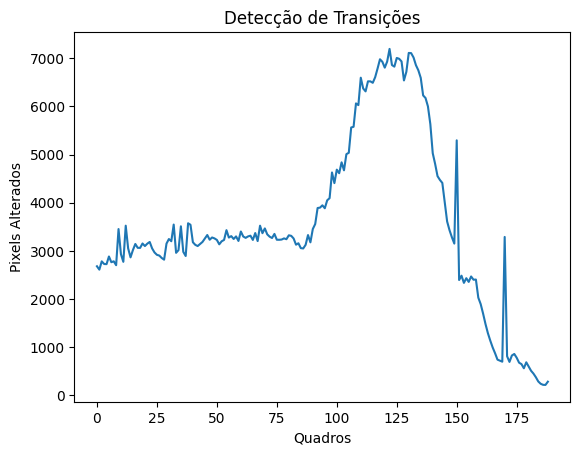

In [22]:
cap = inicializar_imagem()

quadro_anterior = None

metricas = []
indices = []

largura = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
altura  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

tamanho = largura * altura

por = 0.5

# 60% dos pixels do quadro devem ser diferentes para considerar uma transição.
T1 = 10
T2 = tamanho * por

transicoes = cv2.VideoWriter(f'transicoes/videos/transicoes_pixels_{video}_{T1}_{T2}.mp4', cv2.VideoWriter_fourcc(*'mp4v'), cap.get(cv2.CAP_PROP_FPS), (largura, altura))

# 2. Loop de leitura do vídeo
while cap.isOpened():
    
    ret, frame = cap.read()
    
    
    if not ret:
        break
        
    quadro_cinza = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    

    if quadro_anterior is not None:
        dif = cv2.absdiff(quadro_cinza, quadro_anterior)

        qntd = np.sum(dif > T1)

        metricas.append(qntd)

        if qntd > T2:
            indices.append(int(cap.get(cv2.CAP_PROP_POS_FRAMES)))
            transicoes.write(frame)

        pass
        
    
    quadro_anterior = quadro_cinza

cap.release()
cv2.destroyAllWindows()
transicoes.release()

print("frames de transição:", indices)
plt.plot(metricas, label='Métrica de Diferença')

# Desenha uma linha vermelha tracejada para cada transição detectada
for idx in indices:
    # Subtraímos 2 porque a lista 'metricas' começou a ser preenchida a partir do 2º quadro
    plt.axvline(x=idx - 1, color='red', linestyle='--', alpha=0.5)

plt.title('Detecção de Transições')
plt.xlabel('Quadros')
plt.ylabel('Pixels Alterados')
plt.savefig(f'transicoes/videos/transicoes_pixels_{video}_{T1}_{por}.png', dpi=300, bbox_inches='tight')
plt.show()



Diferença entre blocos


Observe que existe um for dentro da função que percorre a lista de blocos, entretanto, por se tratar de um número constante(64) optei por não vetorizar já que não percebi impacto direto na eficiencia do código. 

frames de transição: []


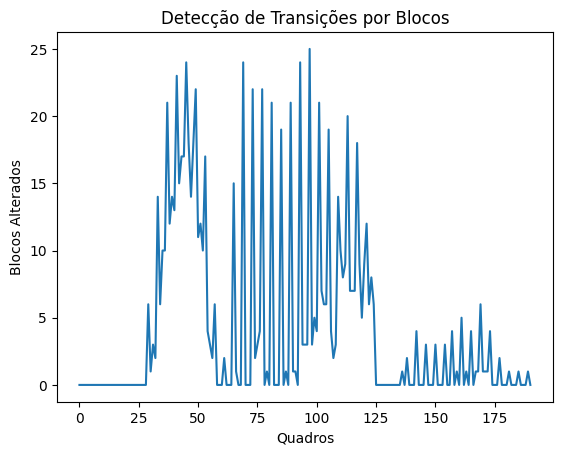

In [29]:
cap = inicializar_imagem()

quadro_anterior = None

metricas = []
indices = []

T1 = 500
T2 = 30

transicoes = cv2.VideoWriter(f'transicoes/videos/transicoes_blocos_{video}_{T1}_{T2}.mp4', cv2.VideoWriter_fourcc(*'mp4v'), cap.get(cv2.CAP_PROP_FPS), (int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))))

largura, altura = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

bloco_h, bloco_w = altura // 8, largura // 8

# 2. Loop de leitura do vídeo
while cap.isOpened():
    
    ret, frame = cap.read()
    qntd = 0
    
    if not ret:
        break
        
    quadro_cinza = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    

    if quadro_anterior is not None:
        lista_blocos = quadro_cinza.reshape(8, bloco_h, 8, bloco_w)
        lista_blocos = lista_blocos.transpose(0, 2, 1, 3).reshape(-1, bloco_h, bloco_w)

        lista_blocos_anterior = quadro_anterior.reshape(8, bloco_h, 8, bloco_w)
        lista_blocos_anterior = lista_blocos_anterior.transpose(0, 2, 1, 3).reshape(-1, bloco_h, bloco_w)

        for i in range(len(lista_blocos)):
            erro = np.mean((lista_blocos[i].astype(int) - lista_blocos_anterior[i].astype(int))**2)

            if (erro > T1):
                qntd += 1

        metricas.append(qntd)

        if qntd >= T2:
            indices.append(int(cap.get(cv2.CAP_PROP_POS_FRAMES)))
            transicoes.write(frame)

        pass
        
    
    quadro_anterior = quadro_cinza

cap.release()
cv2.destroyAllWindows()
transicoes.release()

print("frames de transição:", indices)
plt.plot(metricas, label='Métrica de Diferença')

# Desenha uma linha vermelha tracejada para cada transição detectada
for idx in indices:
    # Subtraímos 2 porque a lista 'metricas' começou a ser preenchida a partir do 2º quadro
    plt.axvline(x=idx - 1, color='red', linestyle='--', alpha=0.5)

plt.title('Detecção de Transições por Blocos')
plt.xlabel('Quadros')
plt.ylabel('Blocos Alterados')
plt.savefig(f'transicoes/videos/transicoes_blocos_{video}_{T1}_{T2}.png', dpi=300, bbox_inches='tight')
plt.show()

Diferença entre histogramas

frames de transição: [ 19  20  21  22  23  24  25  26  28  29  35  36  37  38  39  40  41  42
  43  50  62  63  64  65  66  99 100 101 102 103 104 105 106 107 108 109
 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127
 128 129 130 131 132 133 134 135 136 137 138 139 140]


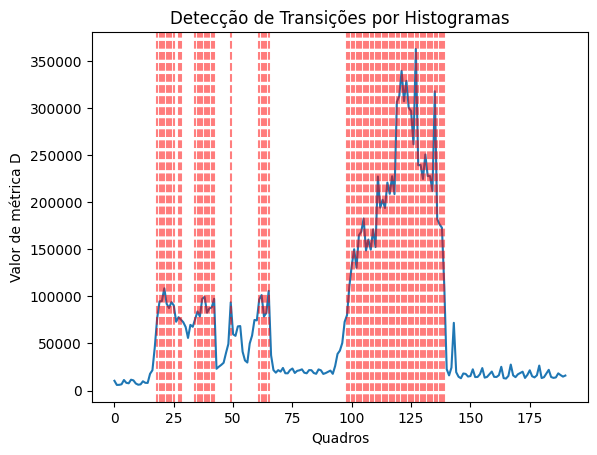

In [33]:
cap = inicializar_imagem()

quadro_anterior = None

metricas = []
indices = []

a = 0

transicoes = cv2.VideoWriter(f'transicoes/videos/transicoes_hist_{video}_{a}.mp4', cv2.VideoWriter_fourcc(*'mp4v'), cap.get(cv2.CAP_PROP_FPS), (int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))))

# Loop de leitura do vídeo
while cap.isOpened():
    
    ret, frame = cap.read()
    
    
    if not ret:
        break
        
    quadro_cinza = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    if quadro_anterior is not None:
        
        hist_quadro = cv2.calcHist([quadro_cinza], channels=[0], mask=None, histSize=[256], ranges=[0, 256])
        hist_quadro_anterior = cv2.calcHist([quadro_anterior], channels=[0], mask=None, histSize=[256], ranges=[0, 256])

        dif = np.abs(hist_quadro - hist_quadro_anterior)
        D = np.sum(dif)

        metricas.append(D)

        pass
        
    
    quadro_anterior = quadro_cinza

cap.release()

T = np.mean(metricas) + a * np.std(metricas)

indices = np.where(np.array(metricas) > T)[0] + 1  # +1 para compensar o início da lista metricas

cap = inicializar_imagem()

contador_frames = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
        
    if contador_frames in indices:
        transicoes.write(frame)
        
    contador_frames += 1

cap.release()
cv2.destroyAllWindows()
transicoes.release()

print("frames de transição:", indices)
plt.plot(metricas, label='Métrica de Diferença')

# Desenha uma linha vermelha tracejada para cada transição detectada
for idx in indices:
    plt.axvline(x=idx - 1, color='red', linestyle='--', alpha=0.5)

plt.title('Detecção de Transições por Histogramas')
plt.xlabel('Quadros')
plt.ylabel('Valor de métrica D')
plt.savefig(f'transicoes/videos/transicoes_hist_{video}_{a}.png', dpi=300, bbox_inches='tight')
plt.show()
